# Chronophenotyping AF 

This notebook demonstrates the workflow for:
1. **Preprocessing R-peaks annotation data** from the **SHDB-AF** dataset for prediction.
2. **Training a classifier on the shorth-term AFB** from tlhe.
3. **Running the trained classifier model** for **AF chronophenotypes identification** using the preprocessed data.

---

### Dataset:
- **SHDB-AF**: The dataset used in this example is the [SHDB-AF dataset](https://physionet.org/content/shdb-af/1.0.1/), which contains ECG signals annotated with peak information and AF-related labels.

### Dataset Details:
- **R-peak annotations**: The location of R-peaks in the ECG signal.
- **AF labels per peak**: Each R-peak is annotated with a label indicating whether it is associated with **AF** or not.
- **Patient information**: The dataset includes the time of day when the Holter recording was initiated.

This notebook will help demonstrate how to prepare the data for prediction and how to use the trained clssifier to make classify AF recordings into different identified **chronotypes**.


### 1. Import Libraries

In [53]:
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

import yaml
import numpy as np
import pandas as pd
import subprocess
from data.preprocessing import ShortBurdenPreprocessor
from visualization.plots import PhenotypePlots


### 2. Setting Up the Paths
We will first set up paths for data storage and where to save the processed data:

In [55]:
# Setup directories
db_path = '../../plug-and-play/physionet_data'  # Where you'll download the PhysioNet dataset
raw_data_input_path = '../../plug-and-play/results/predictions'  # Where to save the processed data which will be used as input to the model
input_path = '../data'  # Where to save the predictions
results_dir = '../results'  # Where to save the predictions
tables_dir = results_dir + '/tables'
figures_dir = results_dir + '/figures'
models_dir = '../models'  # Where the .pb model is saved

# Create directories if they don't exist
os.makedirs(models_dir, exist_ok=True)
os.makedirs(tables_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)

window_size=60

### 3. Prerequisits

Before running prediction, you need **input data** with AF burden profiles.

**Option A: Use output from ArNet2 (plug-and-play pipeline)**
- Run the `predict_example.ipynb` notebook in `plug-and-play/notebooks/`
- This generates AF window classifications that can be used as input here

**Option B: Use your own data**
- Prepare a CSV with columns: `pat` (patient ID), `start_time` (seconds), `pred` (AF label)

For this example, we assume ArNet2 was already run on the SHDB dataset, and the output is available at: `raw_data_input_path: plug-and-play/results/predictions/`

#### Load data

In [57]:
if not os.path.exists(f"{db_path}/AdditionalData.csv"):
    print(f'For clasisification using SHDB data, download the AdditionalData.csv to {db_path}')
else: 
    meta_df = pd.read_csv(f"{db_path}/AdditionalData.csv")
input_file = pd.read_csv(f"{raw_data_input_path}/shdb_pred_df_full.csv")
print(f"Loaded {len(input_file)} rows")
print(f"Patients: {input_file['patient_id'].nunique()}")

meta_df['start_recording'] = pd.to_timedelta(pd.to_datetime(meta_df['Holter_start_time'], errors='coerce').dt.strftime('%H:%M:%S')).dt.total_seconds()
input_file = input_file.merge(meta_df[['Data_ID', 'start_recording']], left_on='patient_id', right_on='Data_ID').drop(columns=['Data_ID'])
input_file['window_start'] = input_file['start_recording'] + input_file['start_time']

Loaded 172444 rows
Patients: 98


/tmp/ipykernel_237308/1612475188.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  meta_df['start_recording'] = pd.to_timedelta(pd.to_datetime(meta_df['Holter_start_time'], errors='coerce').dt.strftime('%H:%M:%S')).dt.total_seconds()


In [58]:

# Filter positive (AF) predictions
input_file_positive = input_file[input_file['pred'] == True]
print(f"Positive (AF) rows: {len(input_file_positive)}")

# Compute burden profiles (24-hour bins)
preprocessor = ShortBurdenPreprocessor(
    time_col='window_start',   # Column with event times (in seconds)
    patient_col='patient_id',  # Column with patient IDs
    n_bins=24                  # 24 hourly bins
)

burden_profiles = preprocessor.compute_burden_profiles(input_file, input_file_positive)

print(f"\nBurden profiles shape: {burden_profiles.shape}")
print(f"  - Rows (patients): {burden_profiles.shape[0]}")
print(f"  - Columns (hours): {burden_profiles.shape[1]}")
print(burden_profiles.head())

burden_profiles.to_csv(f'{input_path}/shdb_burden_profiles.csv')


Positive (AF) rows: 43382
Computed burden profiles: 98 subjects, 24 time bins

Burden profiles shape: (98, 24)
  - Rows (patients): 98
  - Columns (hours): 24
time_bin          0    1    2         3         4    5         6         7   \
patient_id                                                                    
1           0.000000  0.0  0.0  0.000000  0.000000  0.0  0.000000  0.000000   
2           0.000000  0.0  0.0  0.000000  0.000000  0.0  0.000000  0.000000   
3           0.000000  0.0  0.0  0.164557  0.898876  1.0  0.945652  0.989011   
4           0.000000  0.0  0.0  0.000000  0.000000  0.0  0.000000  0.000000   
5           0.086957  0.0  0.0  0.000000  0.000000  0.0  0.000000  0.000000   

time_bin     8         9   ...        14        15        16   17   18   19  \
patient_id                 ...                                                
1           0.0  0.000000  ...  1.000000  1.000000  1.000000  1.0  1.0  1.0   
2           0.0  0.000000  ...  1.000000  1.000000

### 4. Train and predict
Finally, we train a classifier on the short-term AFB located at `tables_dir` under `chronophenotypes.csv` to make predictions based on the preprocessed data:

#### Train

In [59]:
subprocess.run(['python', '../run_prediction.py', 'train', 
                '--chronophenotypes_file', f"{tables_dir}/chronophenotypes.csv", 
                '--model_output', f"{models_dir}/predictor.pkl"
])


=== Training Phenotype Predictor ===

Loading chronophenotypes from ../results/tables/chronophenotypes.csv...
  Shape: (58995, 25)
  Subjects: 58995
  Burden profile dimensions: 24
Predictor trained on 58995 samples, 5 chronophenotypes
Predictor saved to ../models/predictor.pkl

Training Summary:
  Total samples: 58995
  Chronophenotypes: 5
    Chronophenotype 0: 206 subjects
    Chronophenotype 1: 162 subjects
    Chronophenotype 2: 202 subjects
    Chronophenotype 3: 2584 subjects
    Chronophenotype 4: 55841 subjects


CompletedProcess(args=['python', '../run_prediction.py', 'train', '--chronophenotypes_file', '../results/tables/chronophenotypes.csv', '--model_output', '../models/predictor.pkl'], returncode=0)

#### Predict

In [60]:
env = os.environ.copy()
env['OPENBLAS_NUM_THREADS'] = '1'

result = subprocess.run([
    'python', '../run_prediction.py', 'predict',
    '--input_file', f"{input_path}/shdb_burden_profiles.csv",
    '--model_file', f"{models_dir}/predictor.pkl",
    '--output_file', f'{tables_dir}/shdb_chronophenotypes.csv'
], env=env, capture_output=True, text=True)

print(result.stdout)
if result.returncode != 0:
    print("Error:", result.stderr)


=== Chronophenotype Prediction ===
Predictor loaded from ../models/predictor.pkl

Loading burden profiles from ../data/shdb_burden_profiles.csv...
  Samples: 98

Predicting chronophenotypes...

Predictions saved to ../results/tables/shdb_chronophenotypes.csv

Prediction Summary:
  Chronophenotype 0: 11 subjects (avg confidence: 0.800)
  Chronophenotype 1: 5 subjects (avg confidence: 0.960)
  Chronophenotype 2: 10 subjects (avg confidence: 0.860)
  Chronophenotype 3: 7 subjects (avg confidence: 1.000)
  Chronophenotype 4: 65 subjects (avg confidence: 0.991)



### 4. Visualize the clustering

  - Plotting t-SNE...
Figure saved to ../results/figures/shdb_tsne.png


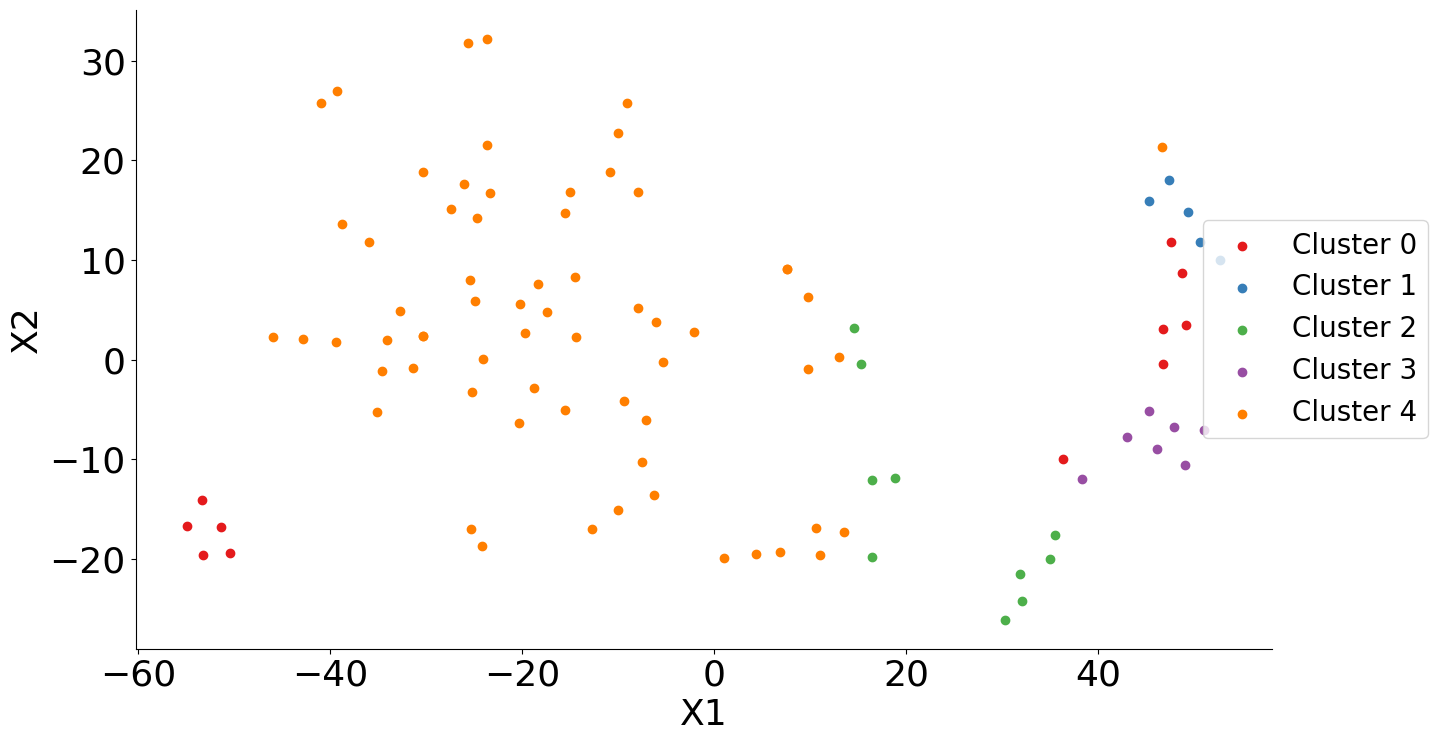

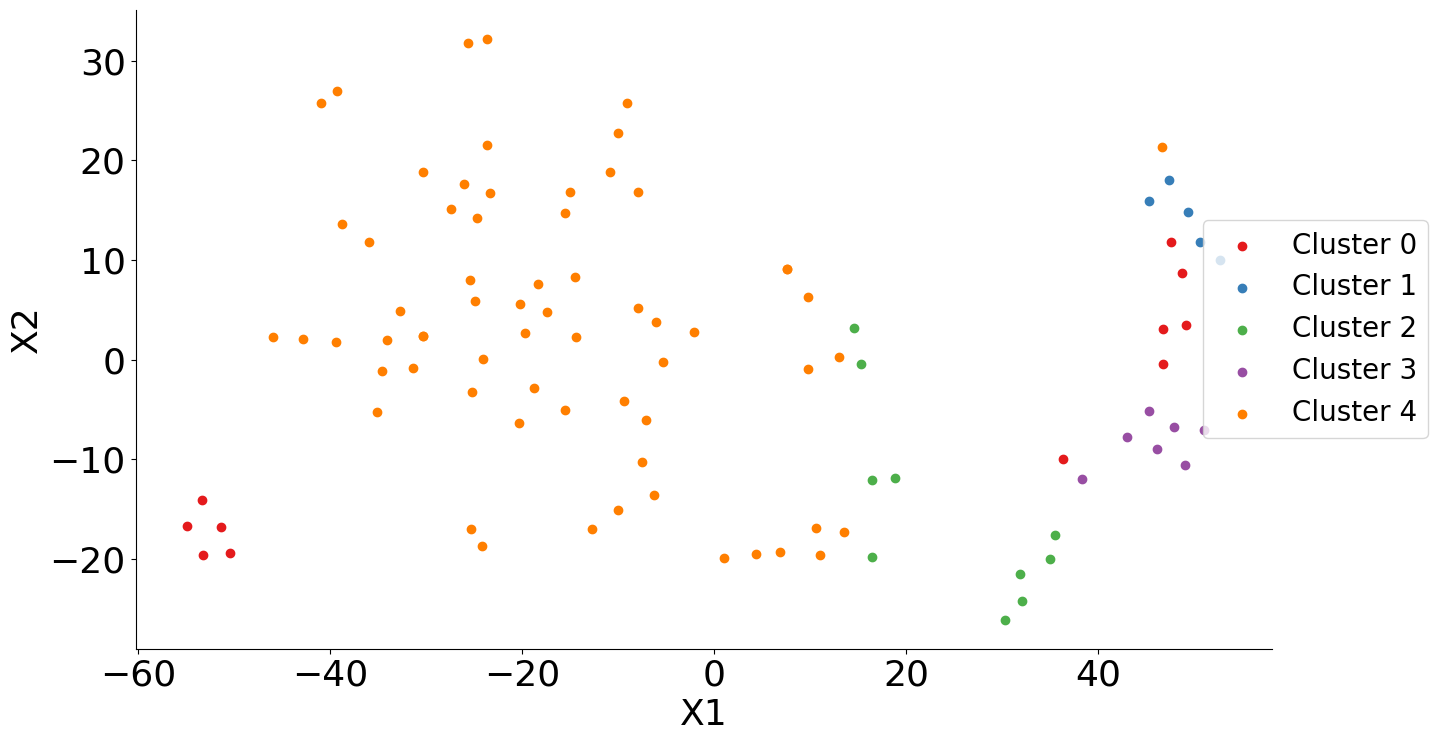

In [61]:
chronophenotypes = pd.read_csv(f'{tables_dir}/shdb_chronophenotypes.csv')

plots = PhenotypePlots()

print("  - Plotting t-SNE...")
plots.plot_tsne(
    burden_profiles.values,
    chronophenotypes.chronophenotype,
    save_path=f"{figures_dir}/shdb_tsne.png"
)

In [ ]:
print("  - Plotting combined chronophenotypes (heatmaps + profiles)...")
plots.plot_chronophenotypes_combined(
    burden_profiles.values,
    chronophenotypes.chronophenotype,
    max_heatmap_samples=50,
    save_path = f"{figures_dir}/shdb_chronophenotypes_combined.png"
)

  - Plotting combined chronophenotypes (heatmaps + profiles)...
Figure saved to ../results/figures/shdb_chronophenotypes_combined.png
